1. Data Loading:

What it does: Loads the Iris dataset directly from the UCI Machine Learning Repository using ucimlrepo and loads the features

Why it is needed: We need to import the raw tabular data into our environment before we can process it or feed it to any algorithm.

Expected outcome: pandas dataframes containing the 4 flower features and their class names.

In [ ]:
import torch
from ucimlrepo import fetch_ucirepo


# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

2. Visualization of raw data:

What it does: Plots a histogram for each of the 4 biological features (sepal length/width, petal length/width).

Why it is needed: To visualize the distribution of the numerical data before training. This helps in understanding the variance and correlations of the features, which motivated the choice of the K-Nearest Neighbors algorithm.

Expected outcome: A grid of 4 histograms showing the frequency distribution of the plant measurements.

In [2]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


array([[<Axes: title={'center': 'sepal length'}>,
        <Axes: title={'center': 'sepal width'}>],
       [<Axes: title={'center': 'petal length'}>,
        <Axes: title={'center': 'petal width'}>]], dtype=object)

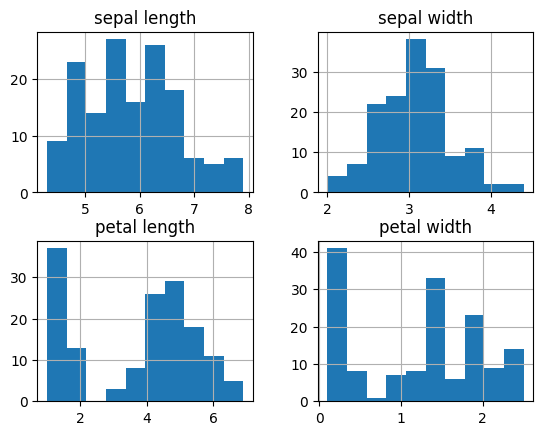

In [3]:
viz = X[["sepal length","sepal width","petal length","petal width"]]
viz.hist()

3. Train/test split

What it does: converts class names to integers (0, 1, 2) and converts the dataframes into pytorch tensors. Also shuffles the data indices using a random seed and splits the tensors into 80% for training and 20% for testing.

Why it is needed: Shuffling prevents the model from being biased by the original sorted order of the dataset.

Expected outcome: Four distinct tensors (f_train, c_train, f_test, c_test) representing the training and testing sets.

In [ ]:
#after seeing the histograms and the correlations I decided to use K-Nearest Negihboors because its the most intuitive method for this
#dataset as classifying the features in 3 classes of Iris
#then the first step is standarizing everything as numbers including the classes

y["class"] = y["class"].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})

In [ ]:
features=X[["sepal length","sepal width","petal length","petal width"]].values

classes=y["class"].values
#now we have the values of features of sepal, petals and classes as an ndarray

#we convert the ndarrays to tensors so I can use pytorch
f = torch.tensor(features)
c = torch.tensor(classes)

print(f[0:5])

tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000]], dtype=torch.float64)


In [ ]:
#we change the index of classes as "shuffling cards" to a specific order to train our model so its not random and biased
torch.manual_seed(67)
i = torch.randperm(len(f))

#we define the cutoff of 80% data
train_size = int(0.8*len(f))

#we take the index of first 80/100 data
train_idx = i[:train_size]
#and the other 20/100
test_idx = i[train_size:]

#features and classes of train (80%)
f_train = f[train_idx] #tensor with the features of the 120 flowers
c_train = c[train_idx] #tensor with the classes (0,1,2) of the 120 flowers

#features and classes of test (20%)
f_test = f[test_idx] #tensor with the features of the 30 flowers to predict
c_test = c[test_idx] #the classes of the 30 flowers


4. Model Definition: K Nearest Neighbors:

What it does: defines a custom K-Nearest Neighbors function from scratch using pytorchs torch.cdist to calculate euclidean distances between the test and train tensors.

Why it is needed: To classify a new flower by finding the "k" closest flowers in the training set and assigning the most common class among them (using torch.mode)

Expected outcome: A functional function capable of predicting classes based on distance.

In [ ]:
def knn(f_train, c_train, f_test, k=67): #k nearest neighbors to analyze
    #matrix 
    #torch.cdist calculates the distance between each row of f_test and all f_train rows so we obtain a matrix 30x120
    distance = torch.cdist(f_test, f_train, p=2) #p=2 means euclidian norm

    #find the k smallest values of distance, thats why we put false in largest and also _, to ignore the index that change the dimension of the tensor
    _,index = torch.topk(distance, k, largest=False)

    votes = c_train[index]

    predictions, _= torch.mode(votes, dim=1)

    return predictions

5. Training loop

In fact the model K Nearest Neighboors doesnt have an iteration training as Neural Networks but we can try another K values to see the performance reflected in acurracy

What it does: Runs the custom KNN function through a loop of odd "k" values (from 1 to 31) to calculate the test precision for each, and plots the results.

Why it is needed: To find the optimal number of neighbors that maximizes accuracy without overfitting to noise or tying.

Expected outcome: A printed list of accuracies, identification of the best "k" (k=5 with 96.67%)

In [9]:
k_values=[1,3,5,7,9,11,13,15,17,19,21,23,31] #we chose odd numbers so its easier to avoid ties
precisionL=[]
for i in k_values:
    preds = knn(f_train, c_train, f_test, k=i)
    correct = (preds==c_test).sum().item()
    precision = (correct/len(c_test))*100
    print(f"Precision of the model with {i} neighbors: {precision:.2f}%")

    precisionL.append(precision)

print(f"the k-value/number of neighbors that optimize the precision of this model is {k_values[precisionL.index(max(precisionL))]} with {max(precisionL):.2f}%")
#if there is a tie in the precision for n-k values i prefer the smallest one because i prioritize computational efficiency by
#ussing less CPU to optimize results

Precision of the model with 1 neighbors: 86.67%
Precision of the model with 3 neighbors: 90.00%
Precision of the model with 5 neighbors: 96.67%
Precision of the model with 7 neighbors: 96.67%
Precision of the model with 9 neighbors: 96.67%
Precision of the model with 11 neighbors: 96.67%
Precision of the model with 13 neighbors: 96.67%
Precision of the model with 15 neighbors: 96.67%
Precision of the model with 17 neighbors: 96.67%
Precision of the model with 19 neighbors: 93.33%
Precision of the model with 21 neighbors: 96.67%
Precision of the model with 23 neighbors: 90.00%
Precision of the model with 31 neighbors: 83.33%
the k-value/number of neighbors that optimize the precision of this model is 5 with 96.67%


6. Evaluation Metrics

We create a graph to see the performance of the model with different numbers of neighbors, we prioritize the smallest one that optimize the model because computational efficiency

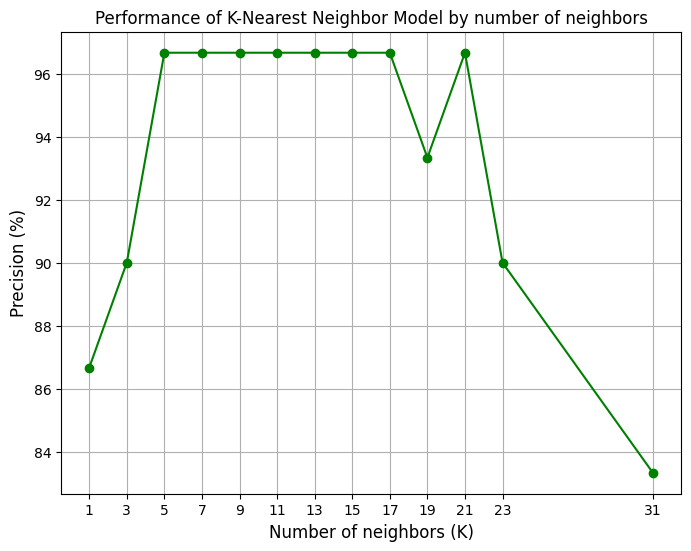

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(k_values, precisionL, marker="o",linestyle="-", color="green")
plt.xticks(k_values)
plt.title("Performance of K-Nearest Neighbor Model by number of neighbors")
plt.xlabel("Number of neighbors (K)",fontsize=12)
plt.ylabel("Precision (%)", fontsize=12)
plt.grid()
plt.show()

7. Decision boundary visualization

In this final step, we visualize the decision boundaries generated by our KNN model. Since our original dataset operates in a 4-dimensional feature space, we project it into a 2D plane using only the first two features (Sepal Length and Sepal Width) for visualization purposes. 

The colored background regions represent the spatial partitions created by the algorithm, indicating where any new point would be classified into one of the three Iris species. 

Why it is needed: To visually how the KNN algorithm draws boundaries between the 3 Iris species in a 2D space, as visualizing 4 dimensions is impossible.

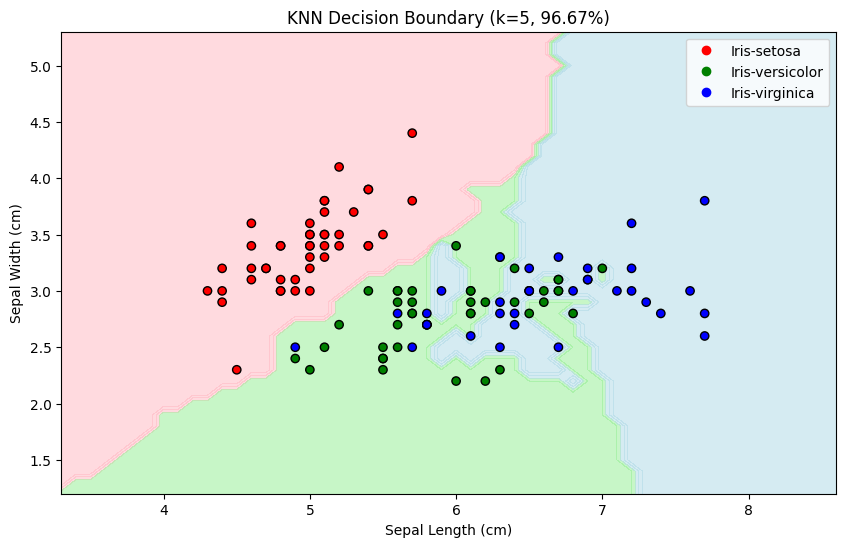

In [16]:
import numpy as np
from matplotlib.colors import ListedColormap

#extract only the first 2 features (sepal length and width)
X_train_2d = f_train[:, :2]

#define grid limits
x_min = X_train_2d[:, 0].min().item() - 1
x_max = X_train_2d[:, 0].max().item() + 1
y_min = X_train_2d[:, 1].min().item() - 1
y_max = X_train_2d[:, 1].max().item() + 1

x1, y1 = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

#convert grid points to tensor
grid_points = np.column_stack((x1.ravel(), y1.ravel()))
grid_tensor = torch.tensor(grid_points, dtype=torch.float64)

#predict grid classes using KNN
predictions = knn(X_train_2d, c_train, grid_tensor, k=3)
Z = predictions.numpy().reshape(x1.shape)

#colors for points and decision zones
cmap_bg = ListedColormap(["lightpink", "lightgreen", "lightblue"])
cmap_pts = ListedColormap(["red", "green", "blue"])


plt.figure(figsize=(10, 6))

#decision zones and data points
plt.contourf(x1, y1, Z, alpha=0.5, cmap=cmap_bg)
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=c_train, cmap=cmap_pts, edgecolor="k")

plt.title(f"KNN Decision Boundary (k={k_values[precisionL.index(max(precisionL))]}, {max(precisionL):.2f}%)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

#legend
clases = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
plt.legend(handles=scatter.legend_elements()[0], labels=clases, loc="upper right")

plt.show()